<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-II/blob/main/Clase%20004/conexion_API_open_meteo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# API-Open-Meteo
### Coderhouse - Data Science
Profe Jorge Ruiz

In [20]:
# Material importante para revisar https://www.nylas.com/blog/use-python-requests-module-rest-apis/

In [21]:
import requests
import pandas as pd
from google.colab import userdata


In [22]:
response = requests.get(f'https://api.open-meteo.com/v1/forecast?latitude=-34.59&longitude=-58.38&current=temperature_2m,relative_humidity_2m,weather_code')
consulta=response.json()
consulta

{'latitude': -34.625,
 'longitude': -58.5,
 'generationtime_ms': 0.034332275390625,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 7.0,
 'current_units': {'time': 'iso8601',
  'interval': 'seconds',
  'temperature_2m': '°C',
  'relative_humidity_2m': '%',
  'weather_code': 'wmo code'},
 'current': {'time': '2026-03-26T19:15',
  'interval': 900,
  'temperature_2m': 26.6,
  'relative_humidity_2m': 35,
  'weather_code': 1}}

In [23]:
import requests

response = requests.get('https://api.open-meteo.com/v1/forecast?latitude=-34.59&longitude=-58.38&daily=temperature_2m_max,temperature_2m_min,relative_humidity_2m_max,relative_humidity_2m_min,weather_code&start_date=2026-03-10&end_date=2026-03-24')
consulta = response.json()
consulta

{'latitude': -34.625,
 'longitude': -58.5,
 'generationtime_ms': 0.11181831359863281,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 7.0,
 'daily_units': {'time': 'iso8601',
  'temperature_2m_max': '°C',
  'temperature_2m_min': '°C',
  'relative_humidity_2m_max': '%',
  'relative_humidity_2m_min': '%',
  'weather_code': 'wmo code'},
 'daily': {'time': ['2026-03-10',
   '2026-03-11',
   '2026-03-12',
   '2026-03-13',
   '2026-03-14',
   '2026-03-15',
   '2026-03-16',
   '2026-03-17',
   '2026-03-18',
   '2026-03-19',
   '2026-03-20',
   '2026-03-21',
   '2026-03-22',
   '2026-03-23',
   '2026-03-24'],
  'temperature_2m_max': [26.5,
   26.9,
   26.7,
   27.2,
   27.5,
   31.6,
   34.6,
   30.8,
   26.7,
   26.5,
   27.4,
   23.3,
   24.6,
   24.2,
   24.7],
  'temperature_2m_min': [18.1,
   17.5,
   19.1,
   19.0,
   19.4,
   19.5,
   23.2,
   19.8,
   16.2,
   16.9,
   19.7,
   17.2,
   11.8,
   17.1,
   9.4],
  'relative_humidity_2m_max': [

In [24]:
print(consulta["daily"]['time'])
print(consulta["daily"]['temperature_2m_max'])
print(consulta["daily"]['temperature_2m_min'])

['2026-03-10', '2026-03-11', '2026-03-12', '2026-03-13', '2026-03-14', '2026-03-15', '2026-03-16', '2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20', '2026-03-21', '2026-03-22', '2026-03-23', '2026-03-24']
[26.5, 26.9, 26.7, 27.2, 27.5, 31.6, 34.6, 30.8, 26.7, 26.5, 27.4, 23.3, 24.6, 24.2, 24.7]
[18.1, 17.5, 19.1, 19.0, 19.4, 19.5, 23.2, 19.8, 16.2, 16.9, 19.7, 17.2, 11.8, 17.1, 9.4]


In [25]:
# vamos a crear un rango de fechas
fechas = pd.date_range(start='2026-03-10', end='2026-03-24', freq='D')  # Frecuencia diaria

#tambien podemos usarlo de esa forma
# fechas = pd.date_range(start='2023-01-01', periods=365, freq='D')

df = pd.DataFrame({'T_max_baires': consulta["daily"]['temperature_2m_max'], "T_min_baires":consulta["daily"]['temperature_2m_min'], 'H_max_baires': consulta["daily"]['relative_humidity_2m_max'], "H_min_baires":consulta["daily"]['relative_humidity_2m_min']}, index=fechas)
df



,T_max_baires,T_min_baires,H_max_baires,H_min_baires
2026-03-10,26.5,18.1,81,36
2026-03-11,26.9,17.5,90,41
2026-03-12,26.7,19.1,88,52
2026-03-13,27.2,19.0,92,48
2026-03-14,27.5,19.4,93,44
2026-03-15,31.6,19.5,90,40
2026-03-16,34.6,23.2,78,39
2026-03-17,30.8,19.8,85,52
2026-03-18,26.7,16.2,93,40
2026-03-19,26.5,16.9,81,34


In [26]:
df.describe()

,T_max_baires,T_min_baires,H_max_baires,H_min_baires
count,15.000000,15.000000,15.000000,15.000000
mean,27.280000,17.593333,88.200000,42.666667
std,2.998857,3.334552,5.747049,11.555250
min,23.300000,9.400000,78.000000,28.000000
25%,25.600000,17.000000,83.000000,35.000000
50%,26.700000,18.100000,90.000000,40.000000
75%,27.450000,19.450000,92.500000,50.000000
max,34.600000,23.200000,97.000000,70.000000


In [27]:
df["T_mean_baires"] = (df["T_max_baires"] + df["T_min_baires"]) / 2

df["H_mean_baires"] = (df["H_max_baires"] + df["H_min_baires"]) / 2
df

,T_max_baires,T_min_baires,H_max_baires,H_min_baires,T_mean_baires,H_mean_baires
2026-03-10,26.5,18.1,81,36,22.30,58.5
2026-03-11,26.9,17.5,90,41,22.20,65.5
2026-03-12,26.7,19.1,88,52,22.90,70.0
2026-03-13,27.2,19.0,92,48,23.10,70.0
2026-03-14,27.5,19.4,93,44,23.45,68.5
2026-03-15,31.6,19.5,90,40,25.55,65.0
2026-03-16,34.6,23.2,78,39,28.90,58.5
2026-03-17,30.8,19.8,85,52,25.30,68.5
2026-03-18,26.7,16.2,93,40,21.45,66.5
2026-03-19,26.5,16.9,81,34,21.70,57.5


In [29]:
# Usar loc con una fecha
print(df.loc['2026-03-22'])

# Usar loc con un rango de fechas
print(df.loc['2026-03-20':'2026-03-22'])

T_max_baires     24.6
T_min_baires     11.8
H_max_baires     88.0
H_min_baires     28.0
T_mean_baires    18.2
H_mean_baires    58.0
Name: 2026-03-22 00:00:00, dtype: float64
            T_max_baires  T_min_baires  H_max_baires  H_min_baires  \
2026-03-20          27.4          19.7            92            57   
2026-03-21          23.3          17.2            97            70   
2026-03-22          24.6          11.8            88            28   

            T_mean_baires  H_mean_baires  
2026-03-20          23.55           74.5  
2026-03-21          20.25           83.5  
2026-03-22          18.20           58.0  


In [30]:
df.describe()

,T_max_baires,T_min_baires,H_max_baires,H_min_baires,T_mean_baires,H_mean_baires
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,27.280000,17.593333,88.200000,42.666667,22.436667,65.433333
std,2.998857,3.334552,5.747049,11.555250,2.916913,7.554248
min,23.300000,9.400000,78.000000,28.000000,17.050000,55.500000
25%,25.600000,17.000000,83.000000,35.000000,21.050000,58.500000
50%,26.700000,18.100000,90.000000,40.000000,22.300000,65.500000
75%,27.450000,19.450000,92.500000,50.000000,23.500000,69.250000
max,34.600000,23.200000,97.000000,70.000000,28.900000,83.500000


In [ ]:
df

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

/tmp/ipykernel_2440/124267772.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")


Text(0.5, 1.0, 'marcha diaria de la temperatura')

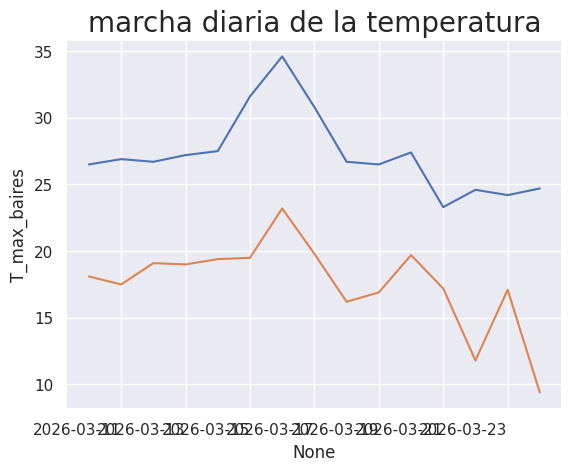

In [32]:
fig,ax = plt.subplots()
sns.lineplot(df, x=df.index, y='T_max_baires')
sns.lineplot(df, x=df.index, y='T_min_baires')
ax.set_xticklabels(ax.get_xticklabels(), ha="right")

plt.title(r'marcha diaria de la temperatura', fontsize=20)






In [34]:
df.to_csv("ejemplo.csv", index=False)


# Actividad a realizar:

1) Optimizar al máximo el gráfico de temperatura utilizado en clase, el cual presenta un amplio margen de mejora. Asegúrese de mejorar aspectos como diseño, claridad y presentación visual.


2) Aplicar el mismo procedimiento para obtener además de temperatura en una ubicación geográfica de su elección, la humedad relativa promedio como variable adicional.


3) Elaborar un gráfico de dispersión (scatter plot) que muestre la relación entre la temperatura promedio y la humedad relativa promedio. Analice e indique si existe alguna correlación entre estas dos variables.



